In [7]:
from pathlib import Path
import shutil
import time

def clean_xpidon_outputs(
    project_root=".",
    backup=True,
    dry_run=True,
):
    """
    Clean old XPIDON training outputs before a new notebook training run.

    Use this BEFORE training.
    Do NOT run this after training and before plotting, otherwise models/loss files will be deleted.

    Parameters
    ----------
    project_root : str
        Project root path. Usually "." if notebook is opened inside XPIDON-Composites.
    backup : bool
        If True, backup current outputs/ and root-level model pkl files before cleaning.
    dry_run : bool
        If True, only print what would be deleted. Set False to actually clean.
    """

    root = Path(project_root).resolve()

    # Safety check: avoid deleting files from wrong directory
    expected_files = ["main.py", "phy_params.json", "exp_params.json", "train_params.json"]
    existing_expected = [f for f in expected_files if (root / f).exists()]

    if len(existing_expected) < 2:
        raise RuntimeError(
            f"Project root may be wrong: {root}\n"
            "Please run this from XPIDON-Composites project root or set project_root correctly."
        )

    print(f"Project root: {root}")
    print(f"Dry run: {dry_run}")
    print(f"Backup: {backup}")

    # Folders generated by training/plotting
    output_subdirs = [
        root / "outputs" / "models",
        root / "outputs" / "loss_data",
        root / "outputs" / "figures",
        root / "outputs" / "predictions",
    ]

    # Root-level files generated by train.py
    root_patterns = [
        "xpidon_class_*_T.pkl",
        "xpidon_class_*_a.pkl",
        "T_temp.pkl",
        "a_temp.pkl",
    ]

    files_to_delete = []
    dirs_to_clean = []

    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)
        dirs_to_clean.append(folder)
        for item in folder.iterdir():
            files_to_delete.append(item)

    for pattern in root_patterns:
        files_to_delete.extend(root.glob(pattern))

    files_to_delete = sorted(set(files_to_delete))

    print("\nFiles/folders that will be cleaned:")
    if not files_to_delete:
        print("  Nothing to clean.")
    else:
        for p in files_to_delete:
            print(" ", p.relative_to(root))

    if dry_run:
        print("\nDry run only. Nothing was deleted.")
        print("Run clean_xpidon_outputs(dry_run=False) to actually clean.")
        return

    # Optional backup
    if backup and files_to_delete:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        backup_dir = root / f"outputs_backup_{timestamp}"
        backup_dir.mkdir(parents=True, exist_ok=True)

        print(f"\nCreating backup: {backup_dir.name}")

        # Backup outputs folder
        outputs_dir = root / "outputs"
        if outputs_dir.exists():
            shutil.copytree(outputs_dir, backup_dir / "outputs", dirs_exist_ok=True)

        # Backup root pkl files
        root_pkl_backup = backup_dir / "root_pkl_files"
        root_pkl_backup.mkdir(exist_ok=True)

        for pattern in root_patterns:
            for file in root.glob(pattern):
                if file.is_file():
                    shutil.copy2(file, root_pkl_backup / file.name)

    # Delete contents
    for p in files_to_delete:
        if p.exists():
            if p.is_file() or p.is_symlink():
                p.unlink()
            elif p.is_dir():
                shutil.rmtree(p)

    # Recreate output folders
    for folder in output_subdirs:
        folder.mkdir(parents=True, exist_ok=True)

    print("\nClean complete.")

In [8]:
clean_xpidon_outputs(dry_run=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: True
Backup: True

Files/folders that will be cleaned:
  Nothing to clean.

Dry run only. Nothing was deleted.
Run clean_xpidon_outputs(dry_run=False) to actually clean.


In [9]:
clean_xpidon_outputs(dry_run=False, backup=True)

Project root: /Users/luzhang/Projects/XPIDON-Composites
Dry run: False
Backup: True

Files/folders that will be cleaned:
  Nothing to clean.

Clean complete.


In [10]:
from utils.phy_params import PhyParams
from utils.exp_params import ExpParams
from utils.train_params import TrainParams
from utils.air_temp import Temp_air
from utils.data_utils import DataGenerator, generate_training_data
from trainer.train import train
from models.pidon import XPIDON
from loss.loss import XPIDONLoss

In [11]:
params = PhyParams('phy_params.json')
exp_params = ExpParams('exp_params.json')
train_params = TrainParams('train_params.json')
init_sub_domain = 1
Tolerance_level =  2e-2
m_inp = 9
branch_layers = [m_inp, 50, 50, 50, 100]
trunk_layers =  [2, 50, 50, 50, 50, 50, 100]
nomad_layers_T = [100, 50, 50, 50, 50, 1]

In [12]:
train(XPIDON, XPIDONLoss, generate_training_data, DataGenerator, Temp_air,params,exp_params,train_params,init_sub_domain,Tolerance_level,m_inp,
          branch_layers ,trunk_layers, nomad_layers_T)


--- Processing Sub-domain: 1/1 ---
Time range: 0.00 to 18800.00 seconds

[DEBUG] Saved generated training data to debug_generated_data/
u_bc_train: (50000, 9)
y_bc_train: (50000, 3)
s_bc_train: (50000, 1)
u_ic_train: (50000, 9)
y_ic_train: (50000, 2)
s_ic_train: (50000, 3)
u_res_train: (250000, 9)
y_res_train_orig: (250000, 2)
s_res_train: (250000, 1)
u_inf_train: (50000, 9)
y_inf_train_orig: (50000, 3)
s_inf_train: (50000, 1)


SystemExit: [DEBUG] Stop after saving generated training data.

In [ ]:
%run plot_training_results.py

Using loss files:
  outputs/loss_data/loss_history_10000.pkl

Merged loss length:
loss_T 1100
loss_a 1100
loss_ics_T 1100
loss_ics_tool 1100
loss_ics_a 1100
loss_bct 1100
loss_bcb 1100
loss_res 1100
loss_res_tool 1100
loss_ode 1100
loss_inf 1100
loss_flux 1100
Saved: outputs/loss_data/loss_history_merged.pkl
Saved: outputs/figures/temperature_network_loss.png
Saved: outputs/figures/doc_network_loss.png

Using model tags:
10000 outputs/models/xpidon_class_10000_T.pkl outputs/models/xpidon_class_10000_a.pkl
Saved: outputs/predictions/final_temperature_doc_prediction.pkl
Saved: outputs/predictions/final_temperature_doc_prediction.csv
Saved: outputs/figures/final_temperature_doc_prediction.png

Done. All generated files are inside outputs/.


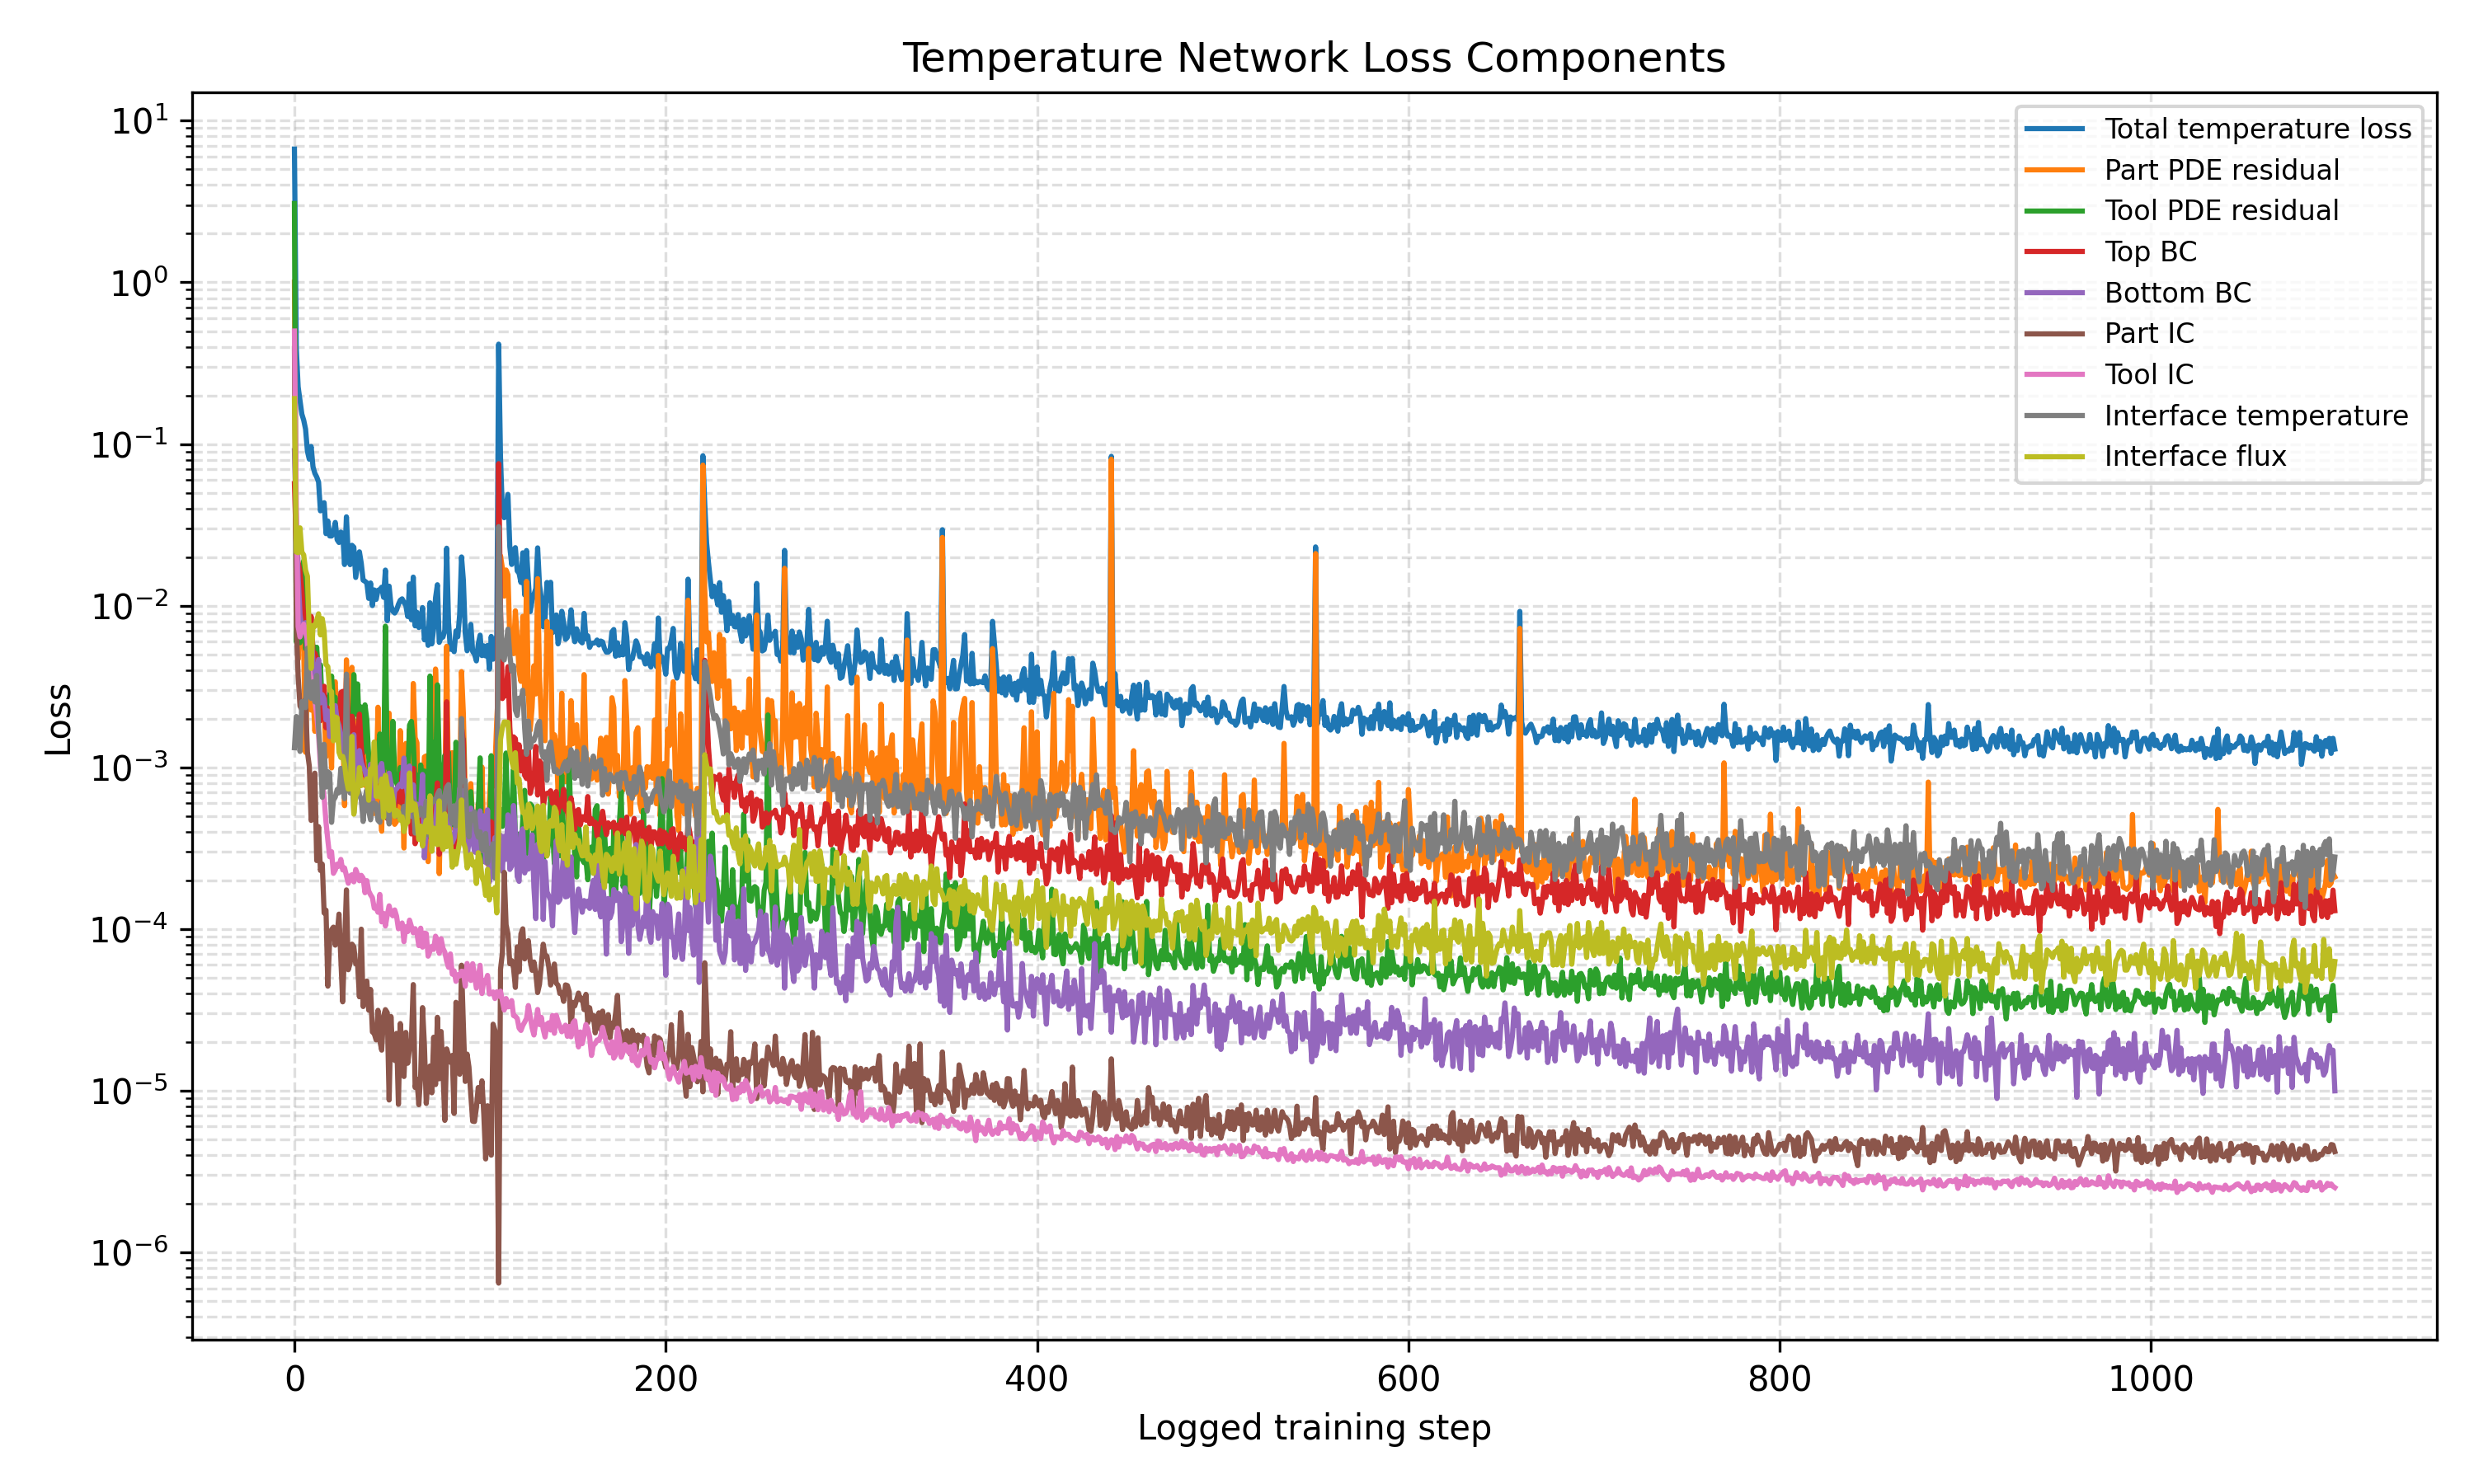

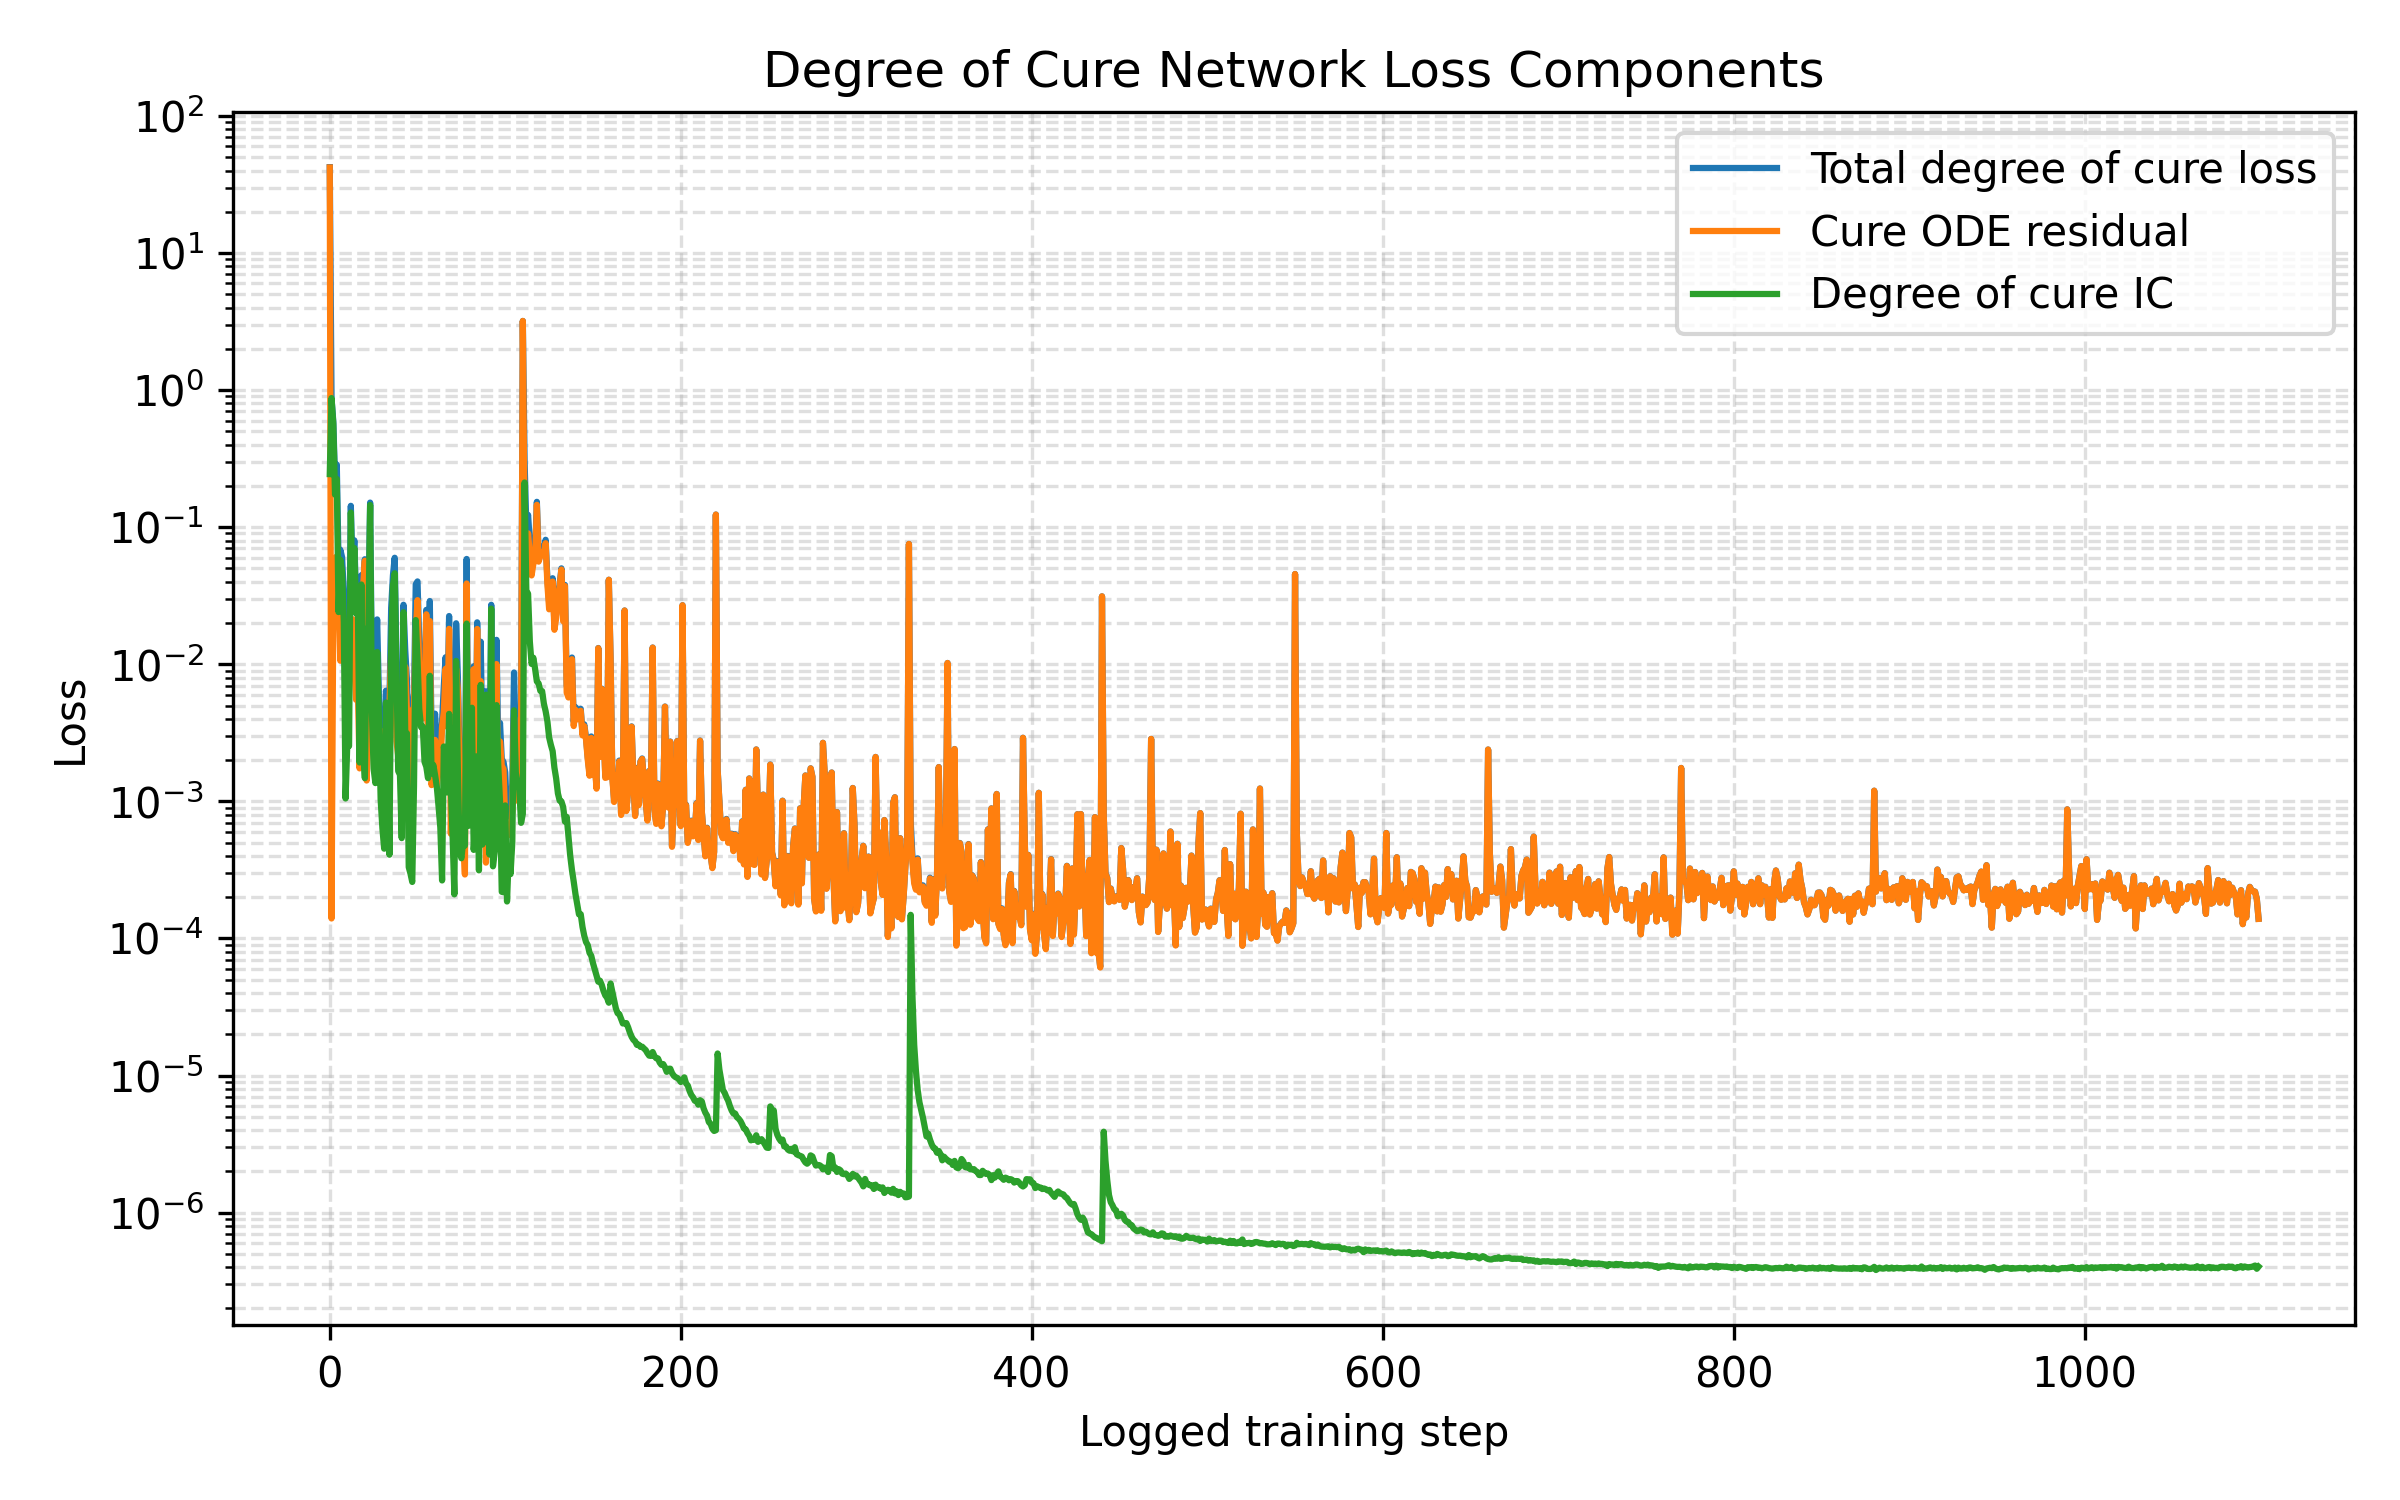

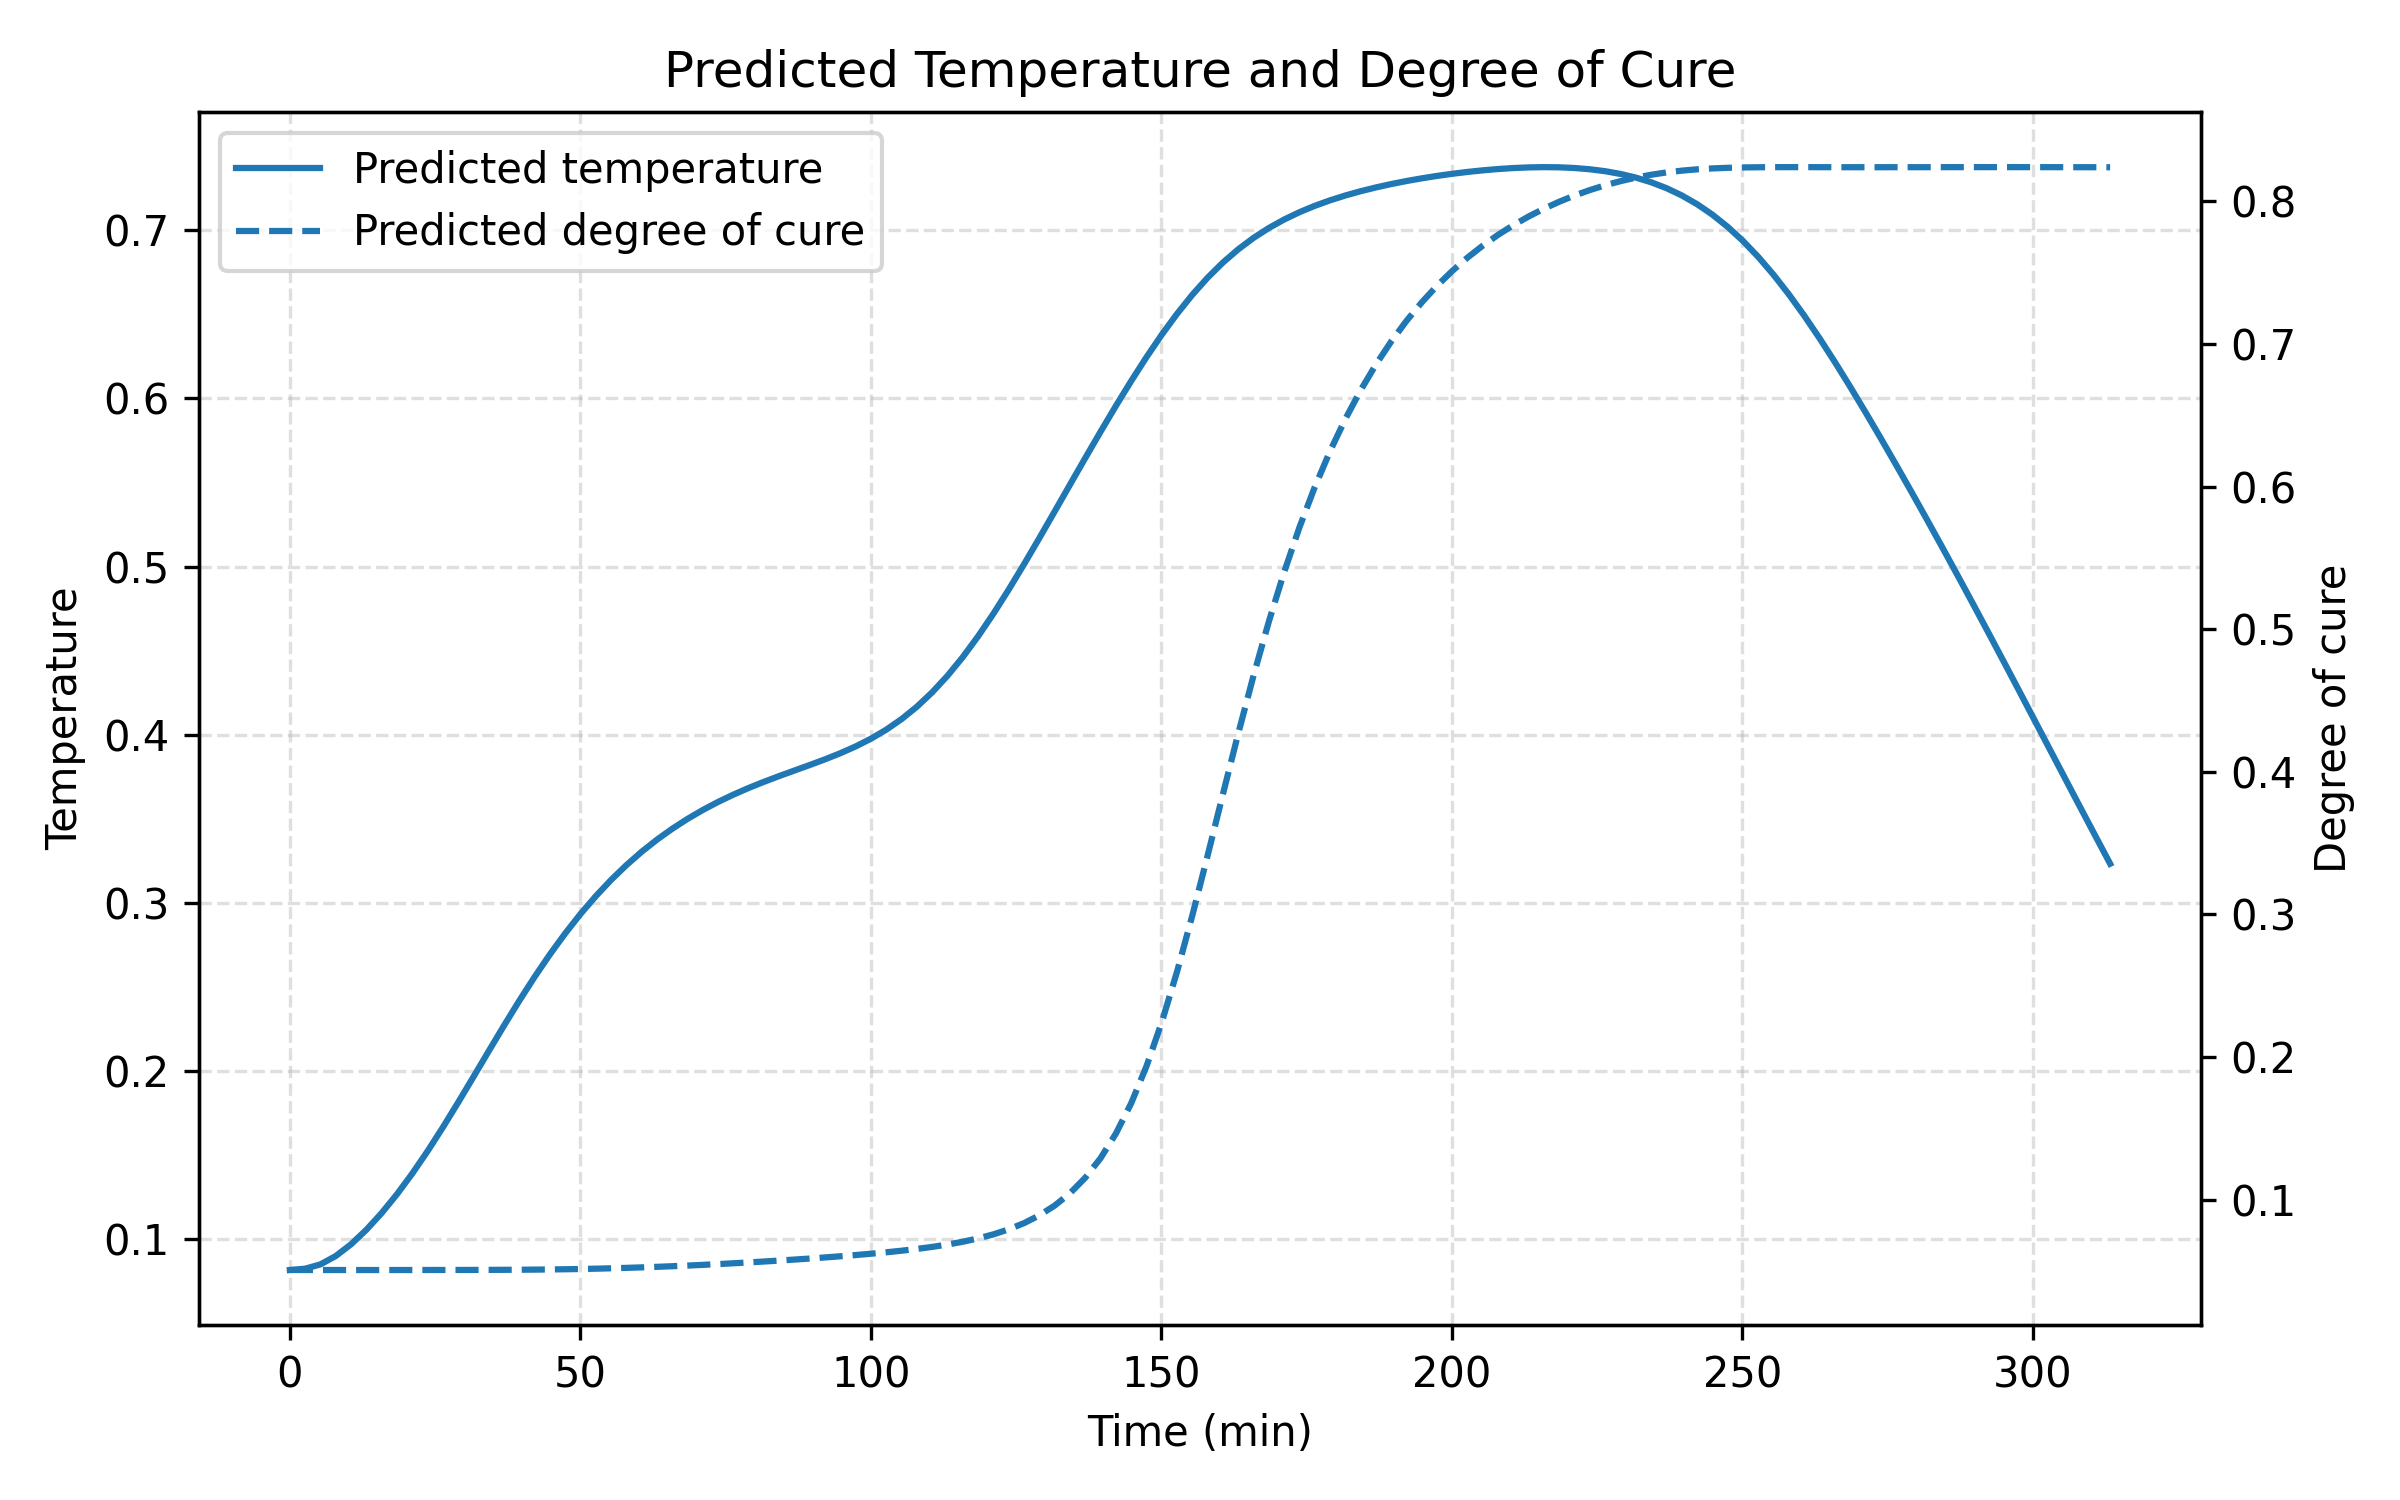

In [ ]:

from IPython.display import Image, display

display(Image("outputs/figures/temperature_network_loss.png"))
display(Image("outputs/figures/doc_network_loss.png"))
display(Image("outputs/figures/final_temperature_doc_prediction.png"))

In [ ]:
from pathlib import Path

print("Model tags:")
for f in sorted(Path("outputs/models").glob("xpidon_class_*_T.pkl")):
    print(f.name)

print("\nLoss files:")
for f in sorted(Path("outputs/loss_data").glob("loss_history_*.pkl")):
    print(f.name)

Model tags:
xpidon_class_10000_T.pkl

Loss files:
loss_history_10000.pkl
loss_history_merged.pkl
